In [1]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 3

In [4]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.ma import MovingAverage
from source.models.arma import ARMA
from source.utils import plot as uplot 
from source.data.loaders import create_dataset
from source.optimize.conditionalss import conditional_square_sum
from source.optimize.likelihood import maximum_likelihood_estimation

%load_ext autoreload
%autoreload 2

In [5]:
arma_model = ARMA(sigma=0.01,
                  phi_params=[0.1, -0.2], 
                  theta_params='stationary',
                  q=2)

In [6]:
print(arma_model)

               AR(2) Model Summary                
Model Order (p)          : 2
Intercept (c)            : 0.0
Error Std Dev (sigma)    : 0.01
Is Stationary            : True
Mu (Unc. Mean):          : 0.0
Sigma (Unc. Std.)        : 0.01
--------------------------------------------------
Coefficients (phi):
  phi_1    =  0.10
  phi_2    = -0.20
               MA(2) Model Summary                
Model Order (p)          : 2
Intercept (c)            : 0.0
Error Std Dev (sigma)    : 0.01
Is Stationary            : True
Mu (Unc. Mean):          : N/A
Sigma (Unc. Std.)        : N/A
--------------------------------------------------
Coefficients (theta):
  theta_1    =  0.22
  theta_2    = -0.09


In [7]:
dataset = create_dataset('./data/base_25.xls')

[INFO] Data loaded successfully!


In [8]:
dataset['pi_t'][:, None].shape

(196, 1)

In [9]:
predmodel_css = conditional_square_sum(arma_model, y_data=dataset['pi_t'])
predmodel_mle = maximum_likelihood_estimation(arma_model, dataset['pi_t'])

In [10]:
nobs = dataset['pi_t'].shape[0]
y_pred_0 = arma_model.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])
y_pred_1 = predmodel_css.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])
y_pred_2 = predmodel_mle.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])

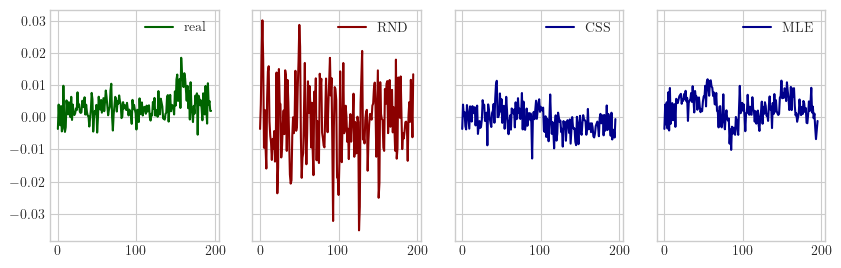

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharey=True)
axes[0].plot(dataset['pi_t'], linestyle='-', color='darkgreen', label='real')
axes[1].plot(y_pred_0, linestyle='-', color='darkred', label='RND')
axes[2].plot(y_pred_1, linestyle='-', color='darkblue', label='CSS')
axes[3].plot(y_pred_2, linestyle='-', color='darkblue', label='MLE')
axes[0].legend()
axes[1].legend()
axes[2].legend()
axes[3].legend()
plt.show()

In [19]:
true_phi = [0.7, 0.2]
true_model_ar = MovingAverage(c=0.5, 
                     sigma=1.0, 
                     theta_params=true_phi)

In [20]:
print(true_model_ar)

               MA(0) Model Summary                
Model Order (p)          : 0
Intercept (c)            : 0.5
Error Std Dev (sigma)    : 1.0
Is Stationary            : True
Mu (Unc. Mean):          : N/A
Sigma (Unc. Std.)        : N/A
--------------------------------------------------
Coefficients (theta):
  (No coefficients for AR(0) model)
